# **Pre-Trained Model 1 - Efficient Net B0**

EfficientNetB0 was selected as the first pretrained architecture for the modelling phase. <br>


### **Why EfficientNet?**

EfficientNet is a CNN (convolutional neural network) built upon the concept of *compound scaling* — jointly scaling network depth, width and resolution via a fixed coefficient, rather than scaling any one dimension in isolation. This yields significantly better accuracy-per-parameter than other architectures.

### **Why B0 specifically?**

B0 is the baseline of the EfficientNet family (φ = 0). With only approximatelly 5M parameters it is the lightest variant, balacing **speed and accuracy**, making it ideal for a constrained medical dataset (~11,000 images). We believe that a heavier variant (B4–B7) would risk overfitting without substantially more data or aggressive regularisation. Therefore, B0 sits at the **optimal point on the bias–variance trade-off for this task**.

#### Moreover, we took into consideration even more specific dataset characteristics for these choice:
- **Suitability for dermoscopy**: Dermoscopic classification relies on fine-grained texture and colour pattern recognition (such as, atypical pigment networks, regression structures and vascular patterns). EfficientNet's depthwise separable convolutions and MBConv blocks are effective at capturing both local texture detail and global spatial context;
- **Transfer learning rationale**: ImageNet pre-training provides a rich, low-level feature initialisation (edges, textures, blobs) that are important for these medical images. Fine-tuning only the top layers in phase 1 prevents catastrophic forgetting of these representations and lets the new classification head converge stably.


### Imports

In [1]:
import tensorflow as tf
#prevent TF from grabbing all GPU memory at once
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
import os
import sys
import keras.applications
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from keras.applications.efficientnet import preprocess_input


if os.getcwd().endswith('models'):
    os.chdir('..')
    
from utils.utils_model import *
from utils.utils_augmentation import *
from utils.utils_preproc import *

In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
print("TF built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available to TF:", tf.test.is_gpu_available())  # deprecated but still works

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available to TF: True


In [4]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        # y_pred are logits
        ce = tf.keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=True
        )
        probs = tf.reduce_max(tf.nn.softmax(y_pred), axis=-1)
        focal_weight = (1 - probs) ** self.gamma
        return focal_weight * ce

### **Data** Configuration

In [5]:
# Load label mapping first — everything else depends on it
with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

N_CLASSES  = len(label2idx)
BATCH_SIZE = 32

train_df = pd.read_csv('data/augmented_metadata.csv')
val_df   = pd.read_csv('data/val_split.csv')
test_df  = pd.read_csv('data/test_split.csv')

# Normalise column names and encode labels for all splits
for df in [train_df, val_df, test_df]:
    if 'cleaned_path' in df.columns and 'image_path' in df.columns:
        df.drop(columns=['image_path'], inplace=True)
    df.rename(columns={'cleaned_path': 'image_path'}, inplace=True)
    df['dx_encoded'] = df['dx'].map(label2idx).astype(int)

# Build datasets
train_ds = make_dataset(train_df, shuffle=True, repeat=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE
class_weights_dict = make_class_weights(train_df)

In [6]:
print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print(f"Class weights: {class_weights_dict}")

Steps per epoch: 394
Class weights: {0: 1.4493569131832797, 1: 1.2340862422997947, 2: 0.8370473537604457, 3: 2.504166666666667, 4: 0.8727008712487899, 5: 0.42867332382310985, 6: 2.3415584415584414}


### **Model** Configuration

In [9]:
def build_efficientnet():
    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
        
    )
    base.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.5)(x)                                      # was 0.4
    x = keras.layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.4)(x)                                      # was 0.3
    outputs = keras.layers.Dense(N_CLASSES)(x)
    return keras.Model(inputs, outputs, name="efficientnet_b0")

Model: "efficientnet_b0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormalization)                                   

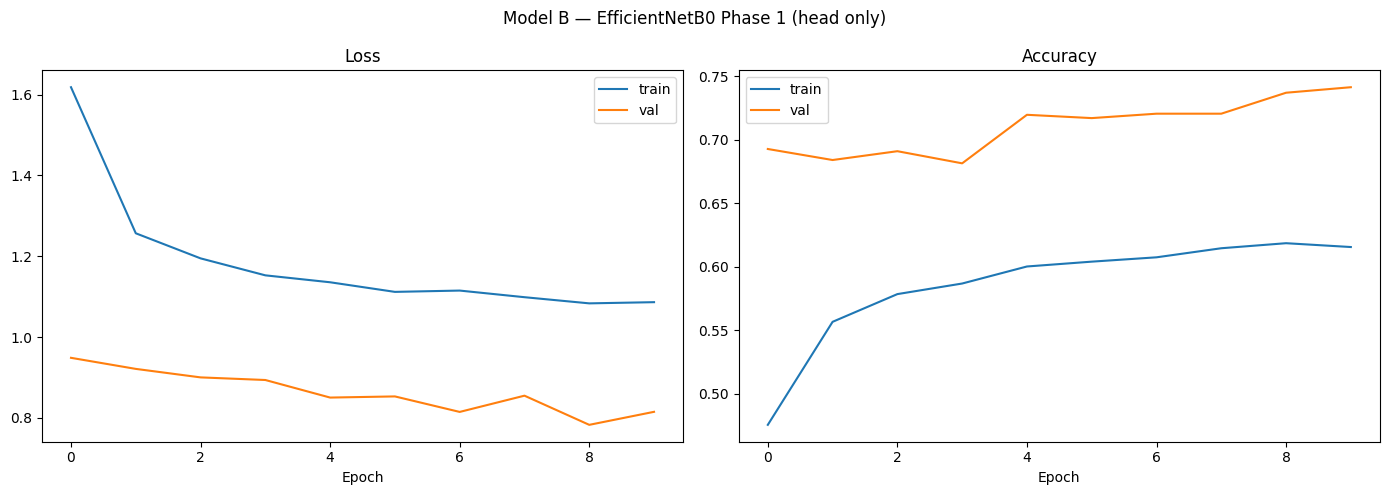

In [10]:
# phase 1: head only
model_pt1 = build_efficientnet() # Model Pre-Trained 1
model_pt1.summary()

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)]
)

history1_pt1 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_b_phase1.weights.h5",
                            patience_es=6, patience_lr=3)

)

plot_history(history1_pt1, "Model B — EfficientNetB0 Phase 1 (head only)")

with open("checkpoints/history_phase1.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history1_pt1.history.items()}, f)

In [ ]:
UNFREEZE_FROM_B = -120

# Phase 2: Fine-tune top layers
base_b = model_pt1.get_layer('efficientnetb0')
base_b.trainable = True

for layer in base_b.layers[:UNFREEZE_FROM_B]:
    layer.trainable = False

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)])

history2_b0 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_b_best.weights.h5",
                        patience_es=10, patience_lr=5))

plot_history(history2_b0, "Model B — EfficientNetB0 Phase 2 (fine-tune)")
results_b = evaluate_model(model_pt1, test_ds, label2idx, "Model B — EfficientNetB0")

Epoch 1/30


In [14]:
with open("checkpoints/history_phase2.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history2_b0.history.items()}, f)

In [ ]:
#394/394 [==============================] - 67s 169ms/step - loss: 0.3377 - accuracy: 0.8473 - balanced_accuracy: 0.8777 - val_loss: 0.6139 - val_accuracy: 0.7752 - val_balanced_accuracy: 0.6575 - lr: 2.5000e-06


### Model Evaluation